In [8]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)

IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

In [9]:
from pathlib import Path

import pandas as pd

# =============================================================================
# The only cell to touch: what to plot, and which CSVs it comes from.
# -----------------------------------------------------------------------------
# RT_COMBINED = False -> RT is two series, NRTI and NNRTI, from the two per-class
#     CSVs (the plot_obs_vs_exp_v2.2_all_c behaviour): four series in every panel.
# RT_COMBINED = True  -> RT is one pooled "NRTI/NNRTI" series from the
#     reverseTranscriptase_both_* CSV (the plot_obs_vs_exp_v2.2_all_RT_combined
#     behaviour): three series in every panel.
#
# The file names are built from the switches below instead of being typed out --
# the rule is the same one DMC_sebset_freq2.7_c_bv_flag.ipynb writes its outputs
# with, so setting the switches here to match that notebook picks up its results.
# =============================================================================
RT_COMBINED = True

CSV_VERSION = 'v17'        # the version suffix on the probability CSVs
USE_TOP_DDE_PAIRS = True   # True -> the ms0_5 top-ddE pair lists ("_topdde_..." files)
# per protein, only used when USE_TOP_DDE_PAIRS -- must match the DMC notebook
DMC_MIN_PERCENT = {'IN': 1.0, 'PR': 5.0, 'RT': 5.0}
TOP_N_PAIRS = 20           # only used when USE_TOP_DDE_PAIRS -- must match the DMC notebook
NON_OVERLAPPING = False     # False -> the "_with_overlap" files: gain of fitness without the
                           #          contender rule (DMC_sebset_freq2.7.1_c_overlap_flag)


def _pct_tag(protein=None):
    """The threshold part of a name: one protein's cut for a CSV, or all three for the
    figure, which draws every protein and so belongs to no single threshold."""
    if protein is not None:
        return f"topdde_{DMC_MIN_PERCENT[protein]:g}pct"
    return "topdde_" + "_".join(f"{p}{DMC_MIN_PERCENT[p]:g}" for p in ('IN', 'PR', 'RT')) + "pct"


def out_name(stem, protein=None):
    """CSV name for `stem`, following the DMC notebook's out_name()."""
    tags = [f"{stem}_{CSV_VERSION}"]
    if USE_TOP_DDE_PAIRS:
        tags.append(_pct_tag(protein))
        if TOP_N_PAIRS is not None:
            tags.append(f"top{TOP_N_PAIRS}")
    if not NON_OVERLAPPING:
        tags.append("with_overlap")
    return "_".join(tags) + ".csv"


def load_probs(stem, protein):
    """Read the probability CSV for `stem`, naming the alternatives if it is missing."""
    path = Path(out_name(stem, protein))
    if not path.exists():
        available = sorted(p.name for p in Path('.').glob(f"{stem}_*.csv"))
        raise FileNotFoundError(
            f"{path} not found -- check CSV_VERSION / USE_TOP_DDE_PAIRS / DMC_MIN_PERCENT / "
            f"TOP_N_PAIRS / NON_OVERLAPPING against the run that produced it.\n"
            f"Available {stem} files: {available}"
        )
    print(f"  {path}")
    return pd.read_csv(path)


print(f"RT_COMBINED = {RT_COMBINED} -> reading")
df_IN = load_probs('integrase_all_probabilities', 'IN')
df_PR = load_probs('protease_all_probabilities', 'PR')
if RT_COMBINED:
    df_RT = load_probs('reverseTranscriptase_both_probabilities', 'RT')
else:
    df_RT_NRTI = load_probs('reverseTranscriptase_NRTI_probabilities', 'RT')
    df_RT_NNRTI = load_probs('reverseTranscriptase_NNRTI_probabilities', 'RT')

print('All CSV files loaded successfully')

RT_COMBINED = True -> reading
  integrase_all_probabilities_v17_topdde_1pct_top20_with_overlap.csv
  protease_all_probabilities_v17_topdde_5pct_top20_with_overlap.csv
  reverseTranscriptase_both_probabilities_v17_topdde_5pct_top20_with_overlap.csv
All CSV files loaded successfully


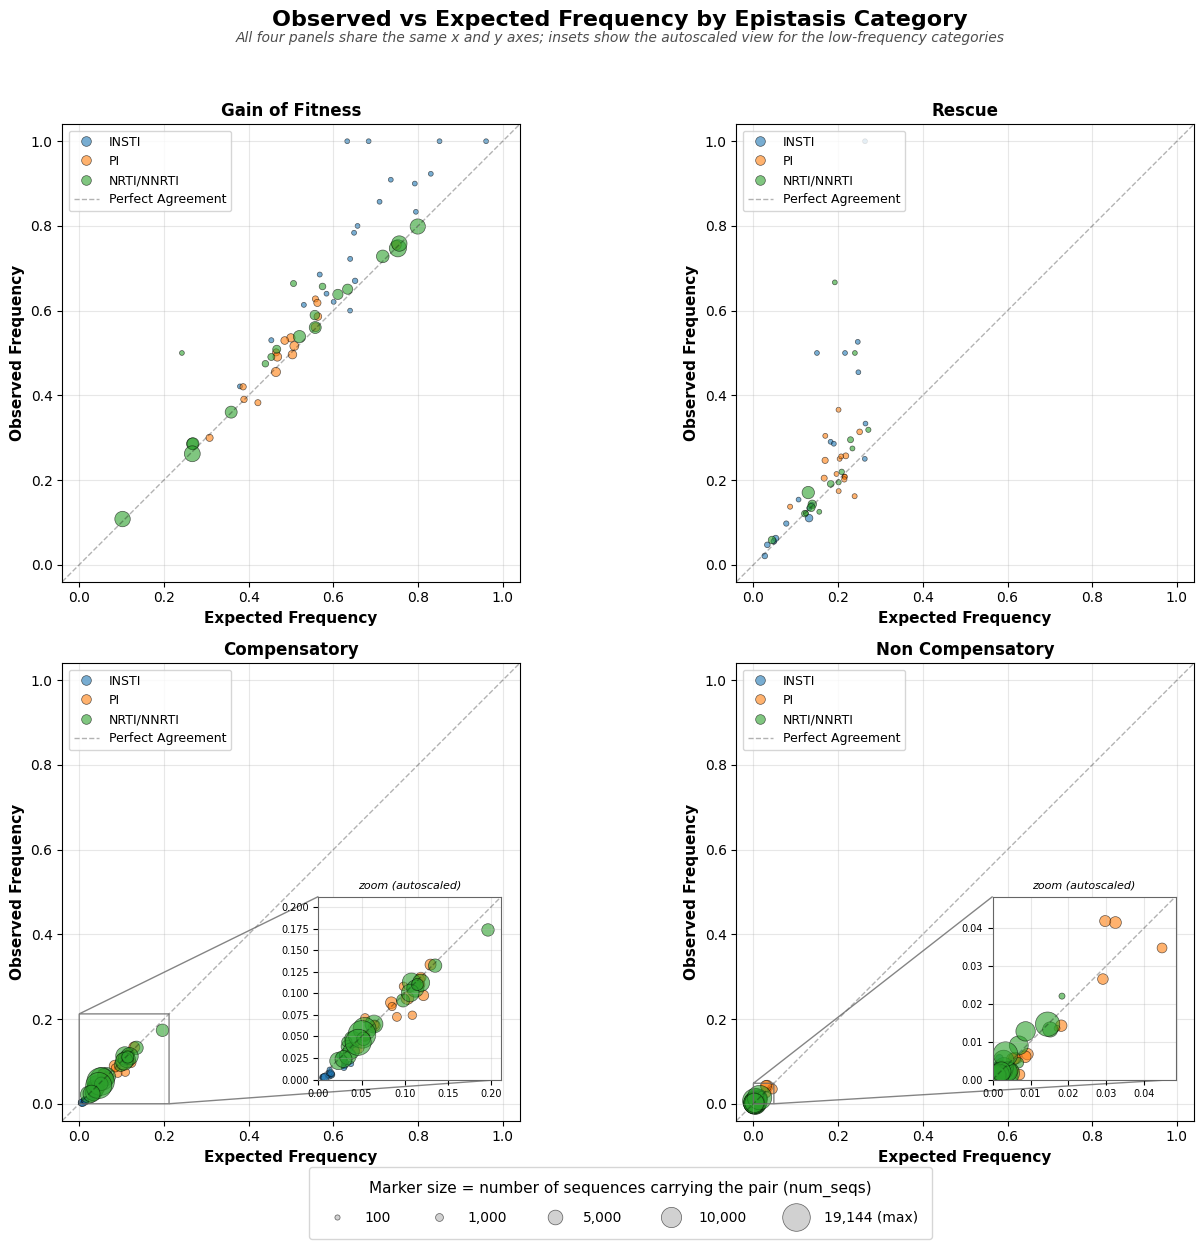

Plot saved as observed_vs_expected_plot_shared_axes_RT_combined_v17_topdde_IN1_PR5_RT5pct_top20_with_overlap.png  (num_seqs range 1-19,144)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# All four panels share one common set of axes limits so the categories are
# directly comparable; the low-frequency categories keep the old per-category
# autoscaled view as an inset.

categories = ['Gain_of_function', 'rescue', 'compensatory', 'non_compensatory']
inset_categories = ['compensatory', 'non_compensatory']  # panels that need a zoom

# RT is one series or two, depending on the flag in the cell above; everything
# downstream just loops over `drugs`, so nothing else changes with the mode.
drugs = [
    {'name': 'INSTI', 'df': df_IN, 'color': '#1f77b4', 'size': len(IN_all_seq)},
    {'name': 'PI', 'df': df_PR, 'color': '#ff7f0e', 'size': len(PR_all_seq)},
]
if RT_COMBINED:
    drugs += [{'name': 'NRTI/NNRTI', 'df': df_RT, 'color': '#2ca02c', 'size': len(RT_all_seq)}]
else:
    drugs += [
        {'name': 'NRTI', 'df': df_RT_NRTI, 'color': '#2ca02c', 'size': len(RT_all_seq)},
        {'name': 'NNRTI', 'df': df_RT_NNRTI, 'color': '#d62728', 'size': len(RT_all_seq)},
    ]

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

def get_cat_data(df, category):
    df_cat = df[df['epistasis_subset'] == category]
    df_cat = df_cat.dropna(subset=['average_p_subcategory', 'observed_f_subcategory'])
    df_cat = df_cat[
        (df_cat['average_p_subcategory'] != 0) &
        (df_cat['observed_f_subcategory'] != 0)
    ]
    return df_cat


def plotted_rows():
    """Every row that ends up on the figure, across all categories and drugs."""
    for category in categories:
        for drug in drugs:
            df_cat = get_cat_data(drug['df'], category)
            if len(df_cat):
                yield category, drug, df_cat


# ---- ranges taken from the data that is actually plotted ----
freq_vals = np.concatenate([
    np.concatenate([df_cat['average_p_subcategory'].values,
                    df_cat['observed_f_subcategory'].values])
    for _, _, df_cat in plotted_rows()
])
num_seqs_vals = np.concatenate([df_cat['num_seqs'].values for _, _, df_cat in plotted_rows()])
n_max = int(num_seqs_vals.max())

vmax = freq_vals.max()
pad = 0.04 * vmax
shared_lims = [-pad, vmax + pad]


def marker_size(num_seqs):
    """Marker area, linear in the number of sequences (the original scaling)."""
    return (np.asarray(num_seqs, dtype=float) / 10000) * 200 + 12


def draw_points(ax, category, alpha=0.6):
    """Scatter every drug's points for one category onto ax; returns the drugs present."""
    present = []
    for drug in drugs:
        df_cat = get_cat_data(drug['df'], category)
        if len(df_cat) == 0:
            continue
        present.append(drug)
        ax.scatter(
            df_cat['average_p_subcategory'],
            df_cat['observed_f_subcategory'],
            color=drug['color'],
            alpha=alpha,
            s=marker_size(df_cat['num_seqs']),
            edgecolors='black',
            linewidth=0.5
        )
    return present


def cat_range(category):
    """Min/max over both axes for one category, across all drugs."""
    vals = []
    for drug in drugs:
        df_cat = get_cat_data(drug['df'], category)
        if len(df_cat):
            vals.append(df_cat['average_p_subcategory'].values)
            vals.append(df_cat['observed_f_subcategory'].values)
    vals = np.concatenate(vals)
    return vals.min(), vals.max()


def color_handle(color, name):
    """Fixed-size legend key, so the colour legend never implies a marker size."""
    return Line2D([], [], linestyle='none', marker='o', markersize=7,
                  markerfacecolor=color, markeredgecolor='black',
                  markeredgewidth=0.5, alpha=0.6, label=name)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Observed vs Expected Frequency by Epistasis Category',
             fontsize=16, fontweight='bold', y=0.995)
fig.text(0.5, 0.968,
         'All four panels share the same x and y axes; insets show the autoscaled view '
         'for the low-frequency categories',
         ha='center', fontsize=10, style='italic', color='0.3')

for cat_idx, category in enumerate(categories):
    category_title = category.replace('_', ' ').title()
    if category == 'Gain_of_function':
        category_title = 'Gain of Fitness'
    ax = axes[positions[cat_idx][0], positions[cat_idx][1]]

    present = draw_points(ax, category)

    ax.plot(shared_lims, shared_lims, 'k--', alpha=0.3, linewidth=1)
    ax.set_xlim(shared_lims)
    ax.set_ylim(shared_lims)
    ax.set_aspect('equal')
    ax.set_xlabel('Expected Frequency', fontsize=11, fontweight='bold')
    ax.set_ylabel('Observed Frequency', fontsize=11, fontweight='bold')
    ax.set_title(category_title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    handles = [color_handle(drug['color'], drug['name']) for drug in present]
    handles.append(Line2D([], [], color='k', linestyle='--', alpha=0.3,
                          linewidth=1, label='Perfect Agreement'))
    ax.legend(handles=handles, loc='upper left', fontsize=9)

    # ---- inset: the per-category autoscaled view (the previous figure) ----
    if category not in inset_categories:
        continue

    cmin, cmax = cat_range(category)
    cpad = 0.08 * (cmax - cmin) if cmax > cmin else 0.1 * cmax
    zoom_lims = [max(0.0, cmin - cpad), cmax + cpad]

    axins = ax.inset_axes([0.56, 0.09, 0.40, 0.40])
    draw_points(axins, category)
    axins.plot(zoom_lims, zoom_lims, 'k--', alpha=0.3, linewidth=1)
    axins.set_xlim(zoom_lims)
    axins.set_ylim(zoom_lims)
    axins.set_aspect('equal')
    axins.grid(True, alpha=0.3)
    axins.tick_params(labelsize=7)
    axins.set_title('zoom (autoscaled)', fontsize=8, style='italic')
    for spine in axins.spines.values():
        spine.set_edgecolor('0.4')

    # mark the zoomed region on the main panel
    ax.indicate_inset_zoom(axins, edgecolor='0.4', alpha=0.8, linewidth=1)

# ---- marker size scale bar: round ticks inside the observed range, topped by the
# largest number of sequences that actually occurs (no ticks beyond the data) ----
size_ticks = [t for t in [100, 1000, 5000, 10000] if t < n_max][:4] + [n_max]
size_labels = [f'{t:,}' for t in size_ticks[:-1]] + [f'{n_max:,} (max)']
size_handles = [
    Line2D([], [], linestyle='none', marker='o', markerfacecolor='0.7',
           markeredgecolor='black', markeredgewidth=0.5, alpha=0.6,
           markersize=np.sqrt(marker_size(t)), label=label)
    for t, label in zip(size_ticks, size_labels)
]
fig.legend(
    handles=size_handles,
    title='Marker size = number of sequences carrying the pair (num_seqs)',
    loc='lower center', bbox_to_anchor=(0.5, -0.035), ncol=len(size_ticks),
    frameon=True, fontsize=10, title_fontsize=11,
    handletextpad=1.0, columnspacing=2.5, borderpad=1.0, labelspacing=1.0
)

# the figure name follows the switches too, so the two RT modes never overwrite
# each other and the file says which pair list it came from
png_name = out_name('observed_vs_expected_plot_shared_axes'
                    + ('_RT_combined' if RT_COMBINED else '_RT_split')).replace('.csv', '.png')

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig(png_name, dpi=300, bbox_inches='tight')
plt.show()
print(f'Plot saved as {png_name}  '
      f'(num_seqs range {int(num_seqs_vals.min()):,}-{n_max:,})')